# AIE S2 — Bike Sharing Demand

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/python-ai-engineering/challenges/aie-s2-bike-demand.ipynb)

**Regression.** Predict how many bikes are rented in a given hour,
from the calendar and the weather.

Challenge: <https://ml-arena.com/viewchallenge/183>

This notebook is the worked example. It runs top to bottom and ends
with a scored submission. Five steps, and every later challenge in
the course is the same five:

1. get the data
2. look at it
3. turn it into numbers
4. fit a model and measure it *before* submitting
5. predict the test set and submit

---

## 0. Setup

`pandas`, `seaborn` and `scikit-learn` are already in Colab. The
ML-Arena client is what downloads the data and uploads your answer.

The distribution is called **`mlarena-sdk`** and it imports as
`mlarena`. Do not `pip install mlarena` — that is an unrelated
package by another author, and none of the calls below exist in it.

In [2]:
!pip install -q mlarena-sdk

---

## 1. Get the data

Paste your personal API key from your ML-Arena **Profile** page. It
starts with `mlk_user_`. `download_dataset` writes the three public
files into the working directory.

In [3]:
import mlarena

API_KEY = "mlk_user_1b593eaa7623ad7a_f72264e89cb5705131fe449d19783d2f"   # <- paste yours here
CHALLENGE_ID = 183

client = mlarena.connect(api_key=API_KEY)
client.download_dataset(CHALLENGE_ID, ".")

['./X_train.csv', './y_train.csv', './X_test.csv']

---

## 2. Read it

Three files. `X_train` and `y_train` are what you learn from;
`X_test` is what you must predict. `y_test` does not exist on your
side — that is the whole point of the exercise.

In [4]:
import pandas as pd

X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")["prediction"]
X_test = pd.read_csv("X_test.csv")

print("X_train", X_train.shape, " y_train", y_train.shape, " X_test", X_test.shape)
X_train.head()

X_train (13903, 13)  y_train (13903,)  X_test (3476, 13)


,id,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
0,tr_697a4f76d7de,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0
1,tr_06d8c72b8712,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0
2,tr_1bdcb5a3a494,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0
3,tr_dc2cde95328a,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0
4,tr_26e0022e38ee,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0


`X_train` is (13903, 13): **n = 13,903 observations** and 13 columns,
of which one is the `id`, so **p = 12 features**. The target lives in
a separate file, aligned by `id`.

Check the column types before anything else — they decide what you
are allowed to do with each one.

In [5]:
X_train.dtypes

,0
id,object
season,object
year,int64
month,int64
hour,int64
holiday,bool
weekday,int64
workingday,bool
weather,object
temp,float64


Four columns are text or boolean (`season`, `holiday`, `workingday`,
`weather`) and the rest are numbers. A linear model cannot consume the text ones
as they are; step 3 is about that.

Now the target and the numeric features:

In [6]:
print(y_train.describe().round(2))
X_train.describe().round(2)

count    13903.00
mean       174.64
std        166.96
min          1.00
25%         37.00
50%        130.00
75%        258.00
max        957.00
Name: prediction, dtype: float64


,year,month,hour,weekday,temp,feel_temp,humidity,windspeed
count,13903.00,13903.00,13903.00,13903.00,13532.00,13532.00,13903.00,13208.00
mean,0.38,5.65,11.55,3.00,20.59,24.04,0.62,13.04
std,0.48,3.22,6.91,2.01,8.04,8.75,0.20,8.27
min,0.00,1.00,0.00,0.00,0.82,0.00,0.00,0.00
25%,0.00,3.00,6.00,1.00,13.94,16.66,0.47,7.00
50%,0.00,5.00,12.00,3.00,21.32,25.00,0.62,13.00
75%,1.00,8.00,18.00,5.00,27.06,31.06,0.79,19.00
max,1.00,12.00,23.00,6.00,41.00,50.00,1.00,57.00


---

## 3. Look at it

This is the step that is easiest to skip and cheapest to do. Six
plots, and each one changes a decision you are about to make.

First, put the target back next to the features so seaborn can plot
them together.

In [7]:
df = X_train.assign(count=y_train)
df.head(3)

,id,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,tr_697a4f76d7de,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16
1,tr_06d8c72b8712,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40
2,tr_1bdcb5a3a494,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32


### 3a. The target's distribution

Always look at what you are predicting first.

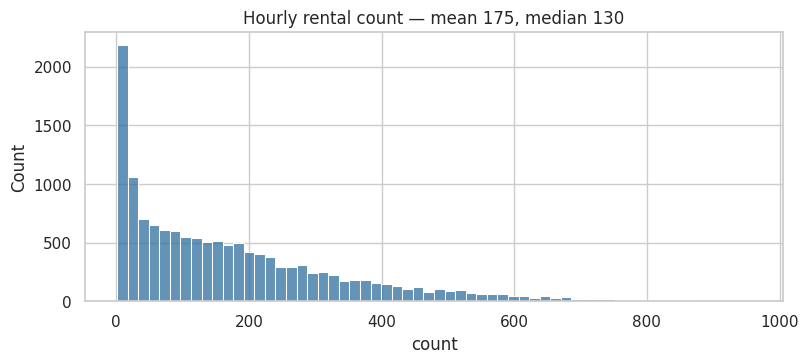

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(df["count"], bins=60, ax=ax, color="#2f6f9f")
ax.set_title(f"Hourly rental count — mean {df['count'].mean():.0f}, median {df['count'].median():.0f}")
ax.set_xlabel("count")
plt.show()

Strongly right-skewed, and bounded below by 0. Two consequences worth
holding on to: the mean sits well above the median, and a model with
an unbounded output — such as a linear one — is free to predict
negative rentals. It will.

### 3b. The hour of the day

The single most informative plot in this dataset. Split it by
`workingday`, because there is no reason a Tuesday and a Sunday should
look alike.

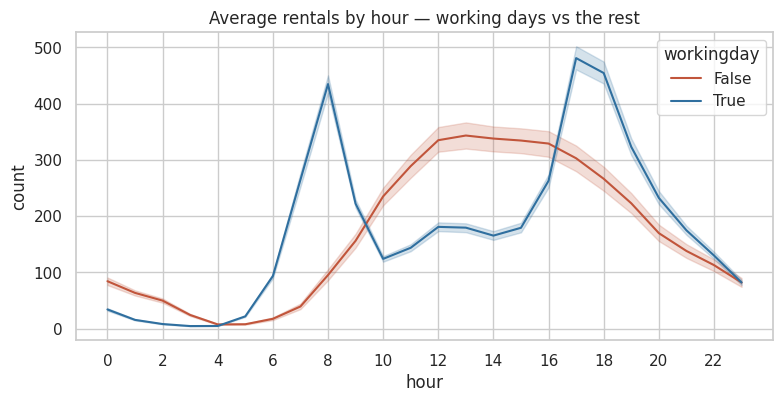

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=df, x="hour", y="count", hue="workingday",
             palette=["#c1553b", "#2f6f9f"], ax=ax)
ax.set_title("Average rentals by hour — working days vs the rest")
ax.set_xticks(range(0, 24, 2))
plt.show()

Two completely different shapes. Working days have a sharp **commute
double peak** at 08:00 and 17:00–18:00; non-working days have a single
broad afternoon hump around 13:00–15:00.

Note what this implies for the model. The relationship between `hour`
and `count` is not a line — it is not even monotone. A model that
multiplies `hour` by one coefficient cannot represent either curve.
Remember this when you read your score.

### 3c. Temperature

The obvious weather candidate.

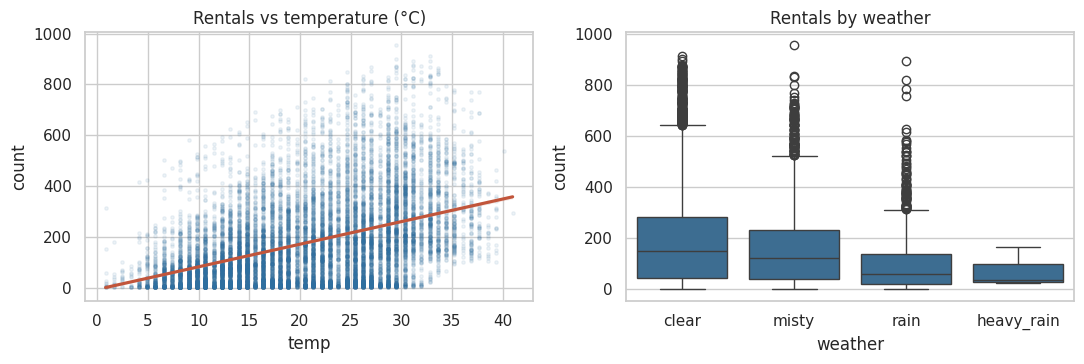

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.regplot(data=df, x="temp", y="count", ax=axes[0],
            scatter_kws=dict(alpha=0.08, s=6, color="#2f6f9f"),
            line_kws=dict(color="#c1553b"))
axes[0].set_title("Rentals vs temperature (°C)")
sns.boxplot(data=df, x="weather", y="count", ax=axes[1],
            order=["clear", "misty", "rain", "heavy_rain"], color="#2f6f9f")
axes[1].set_title("Rentals by weather")
plt.tight_layout()
plt.show()

Warmer is busier, roughly linearly — this one a linear model *can*
use. Weather degrades demand in the order you would guess.

`heavy_rain` is worth a second look: the box is almost invisible
because there are only a handful of such hours in the data. A category
with three observations will not support a reliable coefficient.

`dropna=False` because this column has empty cells, which the default
would hide. That is section 3f.

In [11]:
df["weather"].value_counts(dropna=False)

,count
weather,
clear,9060
misty,3401
rain,1161
NaN,278
heavy_rain,3


### 3d. What correlates with what

A correlation heatmap on the numeric columns, to catch redundancy
before it reaches the model.

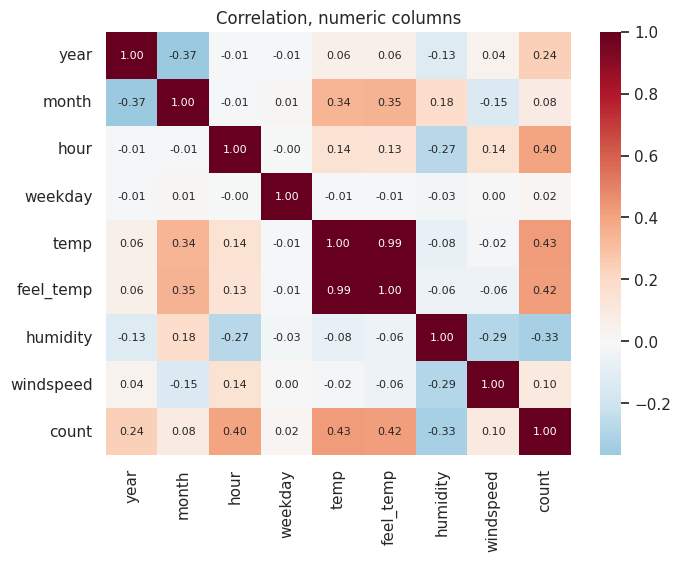

In [12]:
num = df.select_dtypes("number")
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation, numeric columns")
plt.show()

`temp` and `feel_temp` correlate at **0.99** — they are the same
measurement twice. Keeping both is not fatal here, but it makes the
two coefficients individually meaningless: the fit can trade one
against the other freely.

Now look at the `hour` row: it correlates **0.40** with `count`,
about the same as `temp`. Read that against plot 3b, which showed
`hour` driving the target far harder than any other column. The
correlation understates it badly, because correlation measures only
the *linear* part of a relationship and the hour effect rises, falls,
rises and falls again. A single number here cannot see a shape like
that — which is why you plotted it. Section 8 puts a figure on how
much this one column is really worth.

### 3e. Season and year

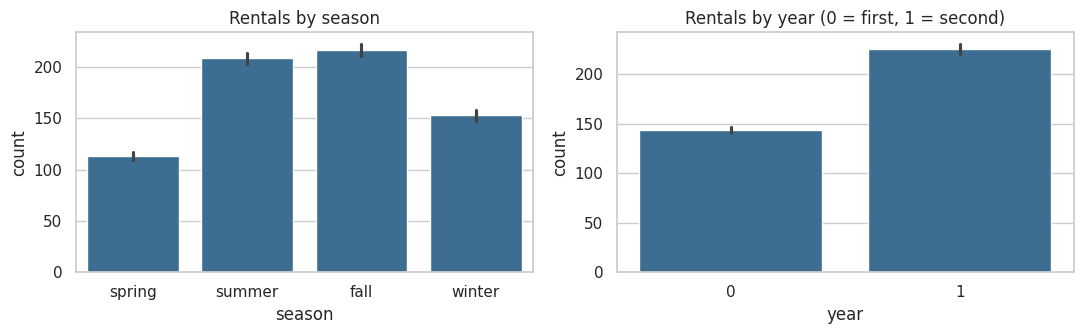

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.barplot(data=df, x="season", y="count", ax=axes[0],
            order=["spring", "summer", "fall", "winter"], color="#2f6f9f")
axes[0].set_title("Rentals by season")
sns.barplot(data=df, x="year", y="count", ax=axes[1], color="#2f6f9f")
axes[1].set_title("Rentals by year (0 = first, 1 = second)")
plt.tight_layout()
plt.show()

The system grew substantially between the two years. `year` is a
genuine feature here, not noise.

### 3f. The holes

Some cells are empty. `sklearn` will not fit through a `NaN`, so this
one is not a matter of taste: skip it and section 5 raises
`ValueError: Input X contains NaN` instead of printing a score.

Count them first, then look at *where* they are.

In [14]:
X_train.isna().sum()

,0
id,0
season,0
year,0
month,0
hour,0
holiday,0
weekday,0
workingday,0
weather,278
temp,371


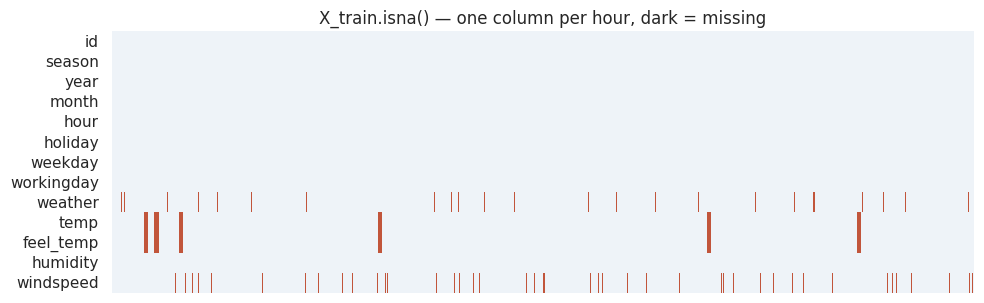

In [15]:
fig, ax = plt.subplots(figsize=(10, 3.2))
sns.heatmap(X_train.isna().T, cbar=False, cmap=["#eef3f8", "#c1553b"],
            ax=ax, xticklabels=False)
ax.set_title("X_train.isna() — one column per hour, dark = missing")
plt.tight_layout()
plt.show()

Two different pictures in one plot, and they mean different things.

- `temp` and `feel_temp` are missing in **solid bands, on the same
  hours** — a thermometer that was down for a couple of days at a
  time.
- `windspeed` and `weather` are **scattered** — individual readings
  dropped, one hour here and one there.

The bands are also why the two temperature columns have to be filled
together: there is no hour where one of them is available to help the
other.

---

## 4. Turn it into numbers

`f(x)` is a function on real vectors, so two things have to go: the
empty cells from 3f and the text columns.

**The holes first.** The quick fill is the median of each numeric
column, and `"unknown"` as a category for the text one. Take the
medians from `X_train` and use those same numbers on `X_test`: a
statistic computed on the data you are predicting is a statistic that
has seen the answer.

This is the cheap fix, not the best one — an annual median is a poor
guess for a thermometer that was down for two days straight, and 3f
showed those outages are runs of consecutive hours, so the hour on
either side is a much better one. `ffill()` or `interpolate()` will
probably score better here. Start with the median, get a number, come
back to it.

**Then the words.** `pd.get_dummies` one-hot encodes every non-numeric
column and leaves the numeric ones alone.

The `reindex` on the second line is not optional. `X_test` may not
contain every category `X_train` does, so encoding the two frames
independently can give them different columns. `reindex` forces the
test matrix to have exactly the training columns, in the same order.

In [16]:
medians = X_train.median(numeric_only=True)   # learned on X_train only

train_filled = X_train.drop(columns=["id"]).fillna(medians).fillna("unknown")
test_filled = X_test.drop(columns=["id"]).fillna(medians).fillna("unknown")
print("NaN left:", int(train_filled.isna().sum().sum()),
      int(test_filled.isna().sum().sum()))

X_train_enc = pd.get_dummies(train_filled)
X_test_enc = pd.get_dummies(test_filled).reindex(
    columns=X_train_enc.columns, fill_value=0)

print("encoded:", X_train_enc.shape, "->", list(X_train_enc.columns[:6]), "...")
assert list(X_train_enc.columns) == list(X_test_enc.columns)

NaN left: 0 0
encoded: (13903, 19) -> ['year', 'month', 'hour', 'holiday', 'weekday', 'workingday'] ...


---

## 5. Fit it and read the numbers

Fit `LinearRegression` on the training matrix, then score it on those
same rows. That is not a slip: in this session you measure the fit on
the data it was fitted to.

You can get away with it *here* because of what the model is. A linear
model has one coefficient per column — 19 of them, against 13,903
rows — so there is nowhere for it to hide an answer it memorised
instead of learned. When that stops being true, and what you do about
it, is Session 3.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

model = LinearRegression().fit(X_train_enc, y_train)
pred = model.predict(X_train_enc)

print(f"R2   {r2_score(y_train, pred):.4f}")
print(f"RMSE {np.sqrt(mean_squared_error(y_train, pred)):.2f}")
print(f"MAE  {mean_absolute_error(y_train, pred):.2f}")

R2   0.4014
RMSE 129.16
MAE  96.51


The challenge ranks on **−MAE** — mean absolute error, negated so
higher is better — so `MAE` is the number to watch; the other two
are context. Read them against the only baseline that matters,
predicting the training mean for every hour:

In [18]:
baseline = np.full(len(y_train), y_train.mean())
print(f"predict-the-mean  MAE  {mean_absolute_error(y_train, baseline):.2f}  R2 {r2_score(y_train, baseline):.4f}")

print(f"negative predictions: {(pred < 0).sum()} of {len(pred)}")

predict-the-mean  MAE  131.08  R2 0.0000
negative predictions: 627 of 13903


So the model does carry real signal — **96.5** against **131.1** for
the mean — but it also predicts a negative number of bicycles 627
times, exactly as plot 3a warned. That is the linear family's
unbounded output space showing up in the output.

---

## 6. Predict the test set and write the submission

`model` is already fitted on all of the training data, so this is one
call. Then write the two required columns.

In [19]:
predictions = model.predict(X_test_enc)

submission = pd.DataFrame({"id": X_test["id"], "prediction": predictions})
submission.to_csv("submission.csv", index=False)

print(submission.shape)
submission.head()

(3476, 2)


,id,prediction
0,te_65ff28c6cf3b,294.478540
1,te_fcf4be0b6635,345.190020
2,te_47c0ff3e2e1d,200.959212
3,te_438dce112a03,261.861130
4,te_d0b72cfc3b23,311.433639


Check the file before uploading it. One row per test id, no missing
values, no duplicates:

In [20]:
assert len(submission) == len(X_test)
assert submission["id"].is_unique
assert submission["prediction"].notna().all()
print("submission.csv looks well-formed")

submission.csv looks well-formed


---

## 7. Submit

In [21]:
#result = client.submit(challenge_id=CHALLENGE_ID, files=["submission.csv"])
#print(result)

In [22]:
#client.leaderboard(CHALLENGE_ID).head(10)

---

## 8. Where to go from here

This model scores about **−MAE = −139** on the challenge's test set.

That is well below the −96.5 section 5 printed, for two reasons that
are both Session 3's subject: section 5 scored the model on the very
rows it was fitted to, and the challenge's test set is the *last* five
months of a system that was still growing. A number measured on data
the model has never seen is a different number, and usually a worse
one.

The challenge page lists the rungs above the benchmark; the first is
worth far more than you would expect, and it is not a change of
model:

- **`hour` is being treated as a number.** The encoding says 23:00 is
  twenty-three times 1:00, and that midnight is a fall of 23 from
  23:00. Plot 3b showed the real shape. Try
  `X_train["hour"] = X_train["hour"].astype(str)` before
  `get_dummies` and re-run — on the challenge's test set it takes
  −MAE from −139 to about −100, with the same `LinearRegression`.
- **Predictions can be negative.** `np.clip(predictions, 0, None)` is
  free and cannot hurt.
- **`temp` and `feel_temp` are the same column twice.** Try dropping
  one.
- `month` and `weekday` have the same problem as `hour`.

Everything past that — trees, ensembles, tuning — is Session 3.